Imports

In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as mvn
import requests
import seaborn as sns

Load Dataset

In [340]:
data = pd.read_csv("cleaned_house_data.csv")

## Define Algorithms

### Linear Regressors

In [341]:
class SimpleLinearReg():

  def fit(self, X,y):
    self.y =y
    self.denominator = np.mean(X**2)-np.mean(X)**2
    self.w1 = (np.mean(X*y)-np.mean(X)*np.mean(y))/self.denominator
    self.w0 = (np.mean(y)*np.mean(X**2)- np.mean(X)*np.mean(X*y))/self.denominator

  def predict(self, X, show=0):

    y_hat = self.w1*X +self.w0

    if show:
      plt.figure()
      plt.scatter(X, self.y, s=8)
      plt.plot(X, y_hat, color="#FF0070")

    return y_hat

In [342]:
class MVLinearRegression():

    def fit(self, X, y, ETA=1e-5, epoch_iterations=10000, show_curve=True):
        ROWS, COLUMNS = X.shape
        ones = np.ones((ROWS, 1))
        X = np.concatenate((ones, X), axis=1)

        self.W = np.zeros(COLUMNS + 1)
        self.J = np.zeros(epoch_iterations)

        for epoch in range(epoch_iterations):

            Y_hat = X @ self.W
            self.J[epoch] = MVOLS(y, Y_hat, ROWS)
            gradient = (1 / ROWS) * (X.T @ (Y_hat - y))
            self.W -= ETA * gradient

        if show_curve:
            plt.figure(figsize=(8,5))
            plt.plot(self.J)
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title("Gradient Descent Loss Curve")
            plt.show()

    def predict(self, X):

        ROWS = X.shape[0]

        ones = np.ones((ROWS, 1))
        X = np.concatenate((ones, X), axis=1)

        return X @ self.W

### OLS

In [343]:
def OLS(Y, Y_hat):
    N = Y_hat.shape[0]
    return (1/(2 *N)) * np.sum((Y - Y_hat) ** 2)

In [344]:
def MVOLS(Y, Y_hat, N):
    return ((1/(2*N))*np.sum((Y-Y_hat)**2))

### KNN

In [345]:
class KNNRegressor():
    def fit(self, X, y):
        self.X = X
        self.y = y
    
    def predict(self, X, K, epsilon = 1e-3):
        N = len(X)
        y_hat = np.zeros(N)

        for i in range(N):
            dist2 = np.sum((self.X - X[i]) ** 2, axis = 1)
            index = np.argsort(dist2)[:K]
            distances = np.sqrt(dist2[index])
            weights = 1 / (distances + epsilon)
            gamma_k = weights / weights.sum()
            y_index = np.asarray(self.y[index]).flatten()
            y_hat[i] = gamma_k.dot(y_index)
        
        return y_hat

### Naive Guassian Bayes Classifier (Just in case)

In [346]:
class GaussNB():
    def fit(self, X, y , epsilon = 1e-3):
        self.likelihoods = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            X_k = X[y==k]
            self.likelihoods[k] = {
                "mean": X_k.mean(axis = 0),
                "cov": X_k.var(axis = 0) + epsilon
          }
            self.priors[k] = len(X_k)/len(X)

    def predict(self, X):
        N, D = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k, l in self.likelihoods.items():
            P_hat[:, k] = mvn.logpdf(X, l["mean"], l["cov"]) + np.log(self.priors[k])
        
        return P_hat.argmax(axis = 1)

Instantiate the classes

In [347]:
slr = SimpleLinearReg()
mvlr = MVLinearRegression()
knnr = KNNRegressor()
gnb = GaussNB()

### Inspect Important Data for Use Case

In [348]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4944 entries, 0 to 4943
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MLS               4944 non-null   int64  
 1   sold_price        4944 non-null   float64
 2   zipcode           4944 non-null   int64  
 3   longitude         4944 non-null   float64
 4   latitude          4944 non-null   float64
 5   lot_acres         4944 non-null   float64
 6   taxes             4944 non-null   float64
 7   year_built        4944 non-null   int64  
 8   bedrooms          4944 non-null   int64  
 9   bathrooms         4944 non-null   float64
 10  sqrt_ft           4944 non-null   float64
 11  garage            4944 non-null   float64
 12  kitchen_features  4944 non-null   str    
 13  fireplaces        4944 non-null   float64
 14  floor_covering    4944 non-null   str    
 15  HOA               4944 non-null   float64
dtypes: float64(10), int64(4), str(2)
memory usage: 618.1 

In [349]:
data['price_per_sqft'] = data['sold_price'] / data['sqrt_ft']


In [350]:
X = data[['latitude', 'longitude', 'sqrt_ft']]
y = np.log1p(data['sold_price'])

In [351]:
correlation = data.drop(columns = ['taxes', 'floor_covering', 'kitchen_features', 'MLS', 'sold_price', 'sqrt_ft', 'latitude', 'longitude']).corr()

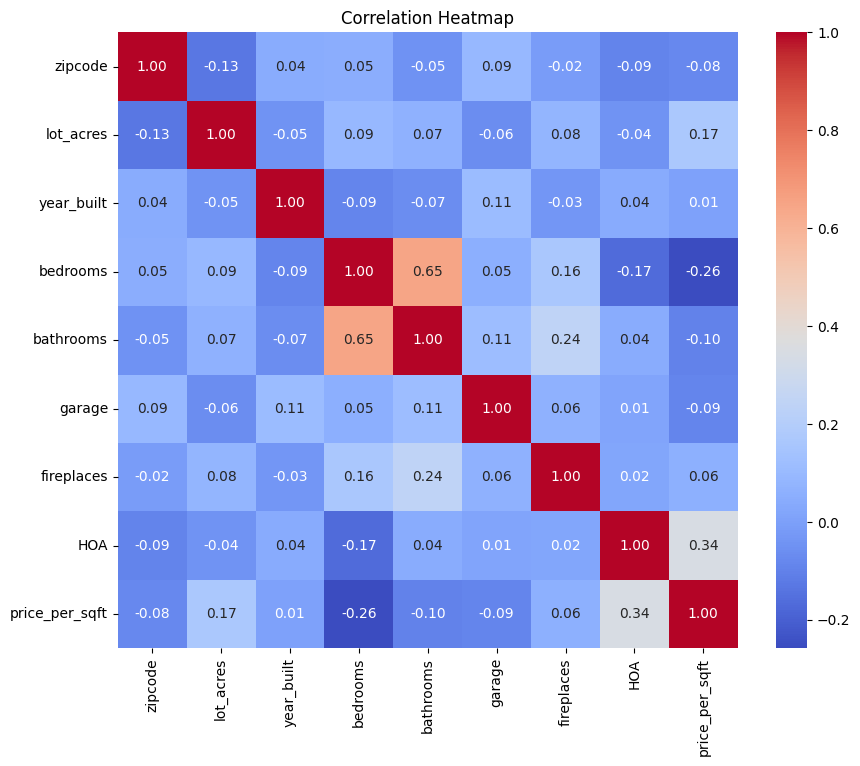

price_per_sqft    1.000000
HOA               0.342701
lot_acres         0.166520
fireplaces        0.059228
year_built        0.006711
zipcode          -0.078570
garage           -0.088764
bathrooms        -0.096312
bedrooms         -0.257971
Name: price_per_sqft, dtype: float64


In [352]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
price_correlations = correlation['price_per_sqft'].sort_values(ascending=False)
print(price_correlations)

In [353]:
data = data[data['sold_price'] < data['sold_price'].quantile(0.99)]
data = data[data['sqrt_ft'] < data['sqrt_ft'].quantile(0.99)]
data['sold_price_log'] = np.log1p(data['sold_price'])



shuffled_data = data.sample(frac = 1.0, random_state = 13).reset_index(drop = True)
training_data = shuffled_data[:int(0.8*len(shuffled_data))].copy()
testing_data = shuffled_data[int(0.8*len(shuffled_data)):].copy()

training_data['lat_sqft'] = training_data['latitude'] * training_data['sqrt_ft']
training_data['long_sqft'] = training_data['longitude'] * training_data['sqrt_ft']

testing_data['lat_sqft'] = testing_data['latitude'] * testing_data['sqrt_ft']
testing_data['long_sqft'] = testing_data['longitude'] * testing_data['sqrt_ft']

zip_code_mean_log = training_data.groupby('zipcode')['sold_price_log'].mean()
sold_price_log_mean = training_data['sold_price_log'].mean()

training_data['zipcode_value'] = training_data['zipcode'].map(zip_code_mean_log)
testing_data['zipcode_value'] = testing_data['zipcode'].map(zip_code_mean_log)

training_data['zipcode_value'] = training_data['zipcode_value'].fillna(sold_price_log_mean)
testing_data['zipcode_value'] = testing_data['zipcode_value'].fillna(sold_price_log_mean)

In [354]:
features = ['latitude', 'longitude', 'sqrt_ft', 'bathrooms', 'bedrooms', 'zipcode_value', 'lat_sqft', 'long_sqft']


X_train = training_data[features].values
X_test = testing_data[features].values
y_train = training_data['sold_price_log'].values
y_test = testing_data['sold_price_log'].values


In [355]:
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

In [356]:
def predict_price(training_data, user_latitude, user_longitude, user_zipcode, zip_mapping, X_train_mean, X_train_std, k = 8):
    latitude_diff = training_data['latitude'].values - user_latitude
    longitude_diff = training_data['longitude'].values - user_longitude
    distance = np.sqrt(latitude_diff**2 + longitude_diff**2)
    nearest_indices = np.argsort(distance)[:k]

    estimated_sqft = training_data['sqrt_ft'].values[nearest_indices].mean()
    estimated_bathrooms = training_data['bathrooms'].values[nearest_indices].mean()
    estimated_bedrooms = training_data['bedrooms'].values[nearest_indices].mean()
    estimated_lat_sqft = user_latitude * estimated_sqft
    estimated_long_sqft = user_longitude * estimated_sqft
    user_lat_sqft = user_latitude * estimated_sqft
    user_long_sqft = user_longitude * estimated_sqft

    zipcode_value = zip_mapping.get(user_zipcode, training_data['sold_price_log'].mean())
    
    features = np.array([[user_latitude, user_longitude, estimated_sqft, estimated_bathrooms, estimated_bedrooms, zipcode_value, user_lat_sqft, user_long_sqft]])
    features_scaled = (features - X_train_mean) / X_train_std

    print(f"Estimated square footage based on nearest neighbors: {estimated_sqft:.2f}")
    print(f"Estimated bathrooms based on nearest neighbors: {estimated_bathrooms:.2f}")
    print(f"Estimated bedrooms based on nearest neighbors: {estimated_bedrooms:.2f}")

    ols_prediction = slr.predict(features_scaled[0, 2], show=0)
    knn_prediction = knnr.predict(features_scaled, K=k)[0]
    mvlr_prediction = mvlr.predict(features_scaled)[0]

    return ols_prediction, knn_prediction, mvlr_prediction

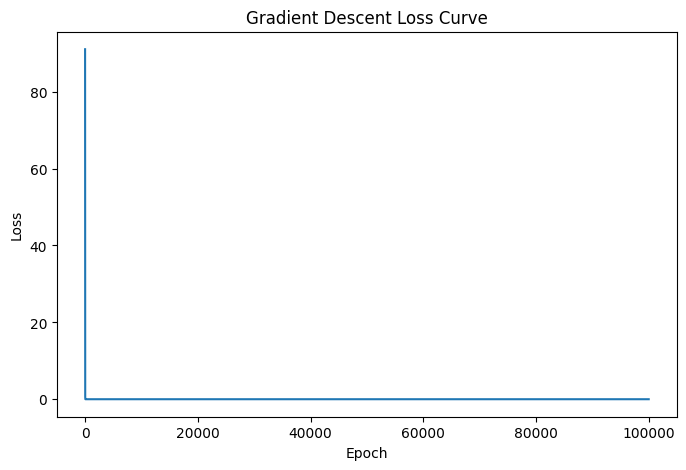

In [357]:
X_train_sqft_scaled = X_train_scaled[:, 2]
slr.fit(X_train_sqft_scaled, y_train)
mvlr.fit(X_train_scaled, y_train, ETA=.1, epoch_iterations=100000, show_curve=True)
knnr.fit(X_train_scaled, y_train)

In [358]:
random_index = np.random.choice(len(X_test_scaled))
sample_latitude = testing_data['latitude'].values[random_index]
sample_longitude = testing_data['longitude'].values[random_index]
sample_zipcode = testing_data['zipcode'].values[random_index]

In [359]:
actual_price_log = y_test[random_index]
actual_price = np.expm1(actual_price_log)

ols_pred_log = slr.predict(X_test_scaled[random_index, 2], show=0)
knn_pred_log = knnr.predict(X_test_scaled[random_index].reshape(1, -1), K=16)[0]
mvlr_pred_log = mvlr.predict(X_test_scaled[random_index].reshape(1, -1))[0]



ols_pred = np.expm1(ols_pred_log)
knn_pred = np.expm1(knn_pred_log)
mvlr_pred = np.expm1(mvlr_pred_log)
predicted_price = predict_price(testing_data, sample_latitude, sample_longitude, sample_zipcode, zip_code_mean_log, X_train_mean, X_train_std, k=20)
print(f"OLS Prediction: ${ols_pred:.2f}")
print(f"KNN Prediction: ${knn_pred:.2f}")
print(f"MVLR Prediction: ${mvlr_pred:.2f}")
print(f"Actual Price: ${actual_price:.2f}")

Estimated square footage based on nearest neighbors: 3642.85
Estimated bathrooms based on nearest neighbors: 3.90
Estimated bedrooms based on nearest neighbors: 3.60
OLS Prediction: $795201.34
KNN Prediction: $947978.62
MVLR Prediction: $825566.83
Actual Price: $1050000.00


In [360]:
def r2_score(y_actual, y_pred):
    residuals = np.sum((y_actual - y_pred) ** 2)
    total = np.sum((y_actual - np.mean(y_actual)) ** 2)

    return 1 - (residuals / total)

In [361]:
ols_test_prediction = slr.predict(X_test_scaled[:, 2], show=0)
knn_test_prediction = np.array(knnr.predict(X_test_scaled, K=18))
mvlr_test_pred = mvlr.predict(X_test_scaled)

In [362]:
print(f"R² Score for OLS: {r2_score(y_test, slr.predict(X_test_scaled[:, 2])):.4f}")
print(f"R² Score for KNN: {r2_score(y_test, knnr.predict(X_test_scaled, K=17)):.4f}")
print(f"R² Score for MVLinearRegression: {r2_score(y_test, mvlr_test_pred):.4f}")

R² Score for OLS: 0.3556
R² Score for KNN: 0.5010
R² Score for MVLinearRegression: 0.4073


In [365]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as mvn
import requests
import seaborn as sns


def jaime_predictor(row, training_data, zip_mapping, X_train_mean, X_train_std, k=18):
    
    if isinstance(row, pd.DataFrame):
        dict_row = row.iloc[0].to_dict()
    elif isinstance(row, pd.Series):
        dict_row = row.to_dict()
    else:
        raise ValueError("Input must be a pandas DataFrame or Series.")
    
    user_latitude = dict_row['latitude']
    user_longitude = dict_row['longitude']
    user_zipcode = dict_row['zipcode']
    user_sqft = dict_row['sqrt_ft']
    user_bathrooms = dict_row['bathrooms']
    user_bedrooms = dict_row['bedrooms']

    sold_price_log_mean = training_data['sold_price_log'].mean()
    zipcode_value = zip_mapping.get(user_zipcode, sold_price_log_mean)

    lat_sqft = user_latitude * user_sqft
    long_sqft = user_longitude * user_sqft

    features = np.array([[user_latitude, user_longitude, user_sqft, user_bathrooms, user_bedrooms, zipcode_value, lat_sqft, long_sqft]])

    features_scaled = (features - X_train_mean) / X_train_std

    ols_predict_log = slr.predict(features_scaled[0, 2], show=0)
    knn_predict_log = knnr.predict(features_scaled, K=k)[0]
    mvlr_predict_log = mvlr.predict(features_scaled)[0]
    actual_price_log = np.log1p(dict_row['sold_price'])
    actual_price = np.expm1(actual_price_log)
    
    ols_predict_dollars = np.expm1(ols_predict_log)
    knn_predict_dollars = np.expm1(knn_predict_log)
    mvlr_predict_dollars = np.expm1(mvlr_predict_log)

    print(f"OLS Prediction: ${ols_predict_dollars:.2f}")
    print(f"KNN Prediction: ${knn_predict_dollars:.2f}")
    print(f"MVLR Prediction: ${mvlr_predict_dollars:.2f}")
    print(f"Actual Price: ${actual_price:.2f}")


In [ ]:
# jaime_test = pd.DataFrame({

In [366]:
jaime_predictor(jaime_test, training_data, zip_code_mean_log, X_train_mean, X_train_std, k=18)

OLS Prediction: $2474951.19
KNN Prediction: $1060235.13
MVLR Prediction: $1195286.03
Actual Price: $5300000.00
